<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/Python-Notebook-Banners/Code_challenge.png"  style="display: block; margin-left: auto; margin-right: auto;";/>
</div>

## Integrated Project: Understanding the yield
© ExploreAI Academy

In this coding challenge, we will apply all of the skills we learned in regression.

⚠️ **Note that this code challenge is graded and will contribute to your overall marks for this module. Submit this notebook for grading. Note that the names of the functions are different in this notebook. Transfer the code in your notebook to this submission notebook**

### Instructions

- **Do not add or remove cells in this notebook. Do not edit or remove the `### START FUNCTION` or `### END FUNCTION` comments. Do not add any code outside of the functions you are required to edit. Doing any of this will lead to a mark of 0%!**

- Answer the questions according to the specifications provided.

- Use the given cell in each question to see if your function matches the expected outputs.

- Do not hard-code answers to the questions.

- The use of StackOverflow, Google, and other online tools is permitted. However, copying a fellow student's code is not permissible and is considered a breach of the Honour code. Doing this will result in a mark of 0%.

# Introduction to simple linear regression

Simple linear regression is a fundamental statistical method used to quantify the relationship between two variables. It allows us to predict an outcome (dependent variable) based on the value of one predictor (independent variable). In this challenge, we will apply simple linear regression to understand how different environmental factors affect the standardised yield of crops.

Our insights will not only help local farmers maximise their harvests but also contribute to the sustainable agriculture practices in Maji Ndogo.



# Initial data exploration

Before we sow the seeds of our regression model, we need to get to know our soil – the dataset. This dataset was developed through extensive agricultural surveys conducted at farms across Maji Ndogo. It contains various factors that might influence a farm's crop yield, from the elevation of the fields to the average temperature they bask in.

Spend some time looking at the data dictionary and start thinking about what could be influencing our crop yield.

# Data dictionary

**1. Geographic features**

- **Field_ID:** A unique identifier for each field (BigInt).

- **Elevation:** The elevation of the field above sea level in metres (Float).

- **Latitude:** Geographical latitude of the field in degrees (Float). (DUMMY VARIABLE- the simulation might have created a relationship)

- **Longitude:** Geographical longitude of the field in degrees (Float). (DUMMY VARIABLE- the simulation might have created a relationship)

- **Location:** Province the field is in (Text).

- **Slope:** The slope of the land in the field (Float).

**2. Weather features**

- **Rainfall:** Amount of rainfall in the area in mm (Float).

- **Min_temperature_C:** Average minimum temperature recorded in Celsius (Float).(DUMMY VARIABLE)

- **Max_temperature_C:** Average maximum temperature recorded in Celsius (Float).(DUMMY VARIABLE)

- **Ave_temps:** Average temperature in Celcius (Float).

**3. Soil and crop features**

- **Soil_fertility:** A measure of soil fertility where 0 is infertile soil, and 1 is very fertile soil (Float).

- **Soil_type:** Type of soil present in the field (Text).

- **pH:** pH level of the soil, which is a measure of how acidic/basic the soil is (Float).

**4. Farm management features**

- **Field_ID:** Corresponding field identifier (BigInt).

- **Pollution_level:** Level of pollution in the area where 0 is unpolluted and 1 is very polluted (Float).

- **Plot_size:** Size of the plot in the field (Ha) (Float). (DUMMY VARIABLE)

- **Chosen_crop:** Type of crop chosen for cultivation (Text).

- **Annual_yield:** Annual yield from the field (Float). This is the total output of the field. The field size and type of crop will affect the Annual Yield (DUMMY VARIABLE - Removed)

<br>

**5. Target variable**
- **Standard_yield:** Standardised yield expected from the field, normalised per crop (Float). This is independent of field size, or crop type. Multiplying this number by the field size, and average crop yield will give the Annual_Yield.

---

Let's import our database again, like we did last time. We won't use the weather data so it is commented out.

**Important:** Ensure that `data_ingestion.py` file and the `field_data_processor.py` files are stored in the same folder as your notebook, otherwise the data import will fail. The links to the files are below:

[Download files here](https://github.com/Explore-AI/Public-Data/raw/master/Maji_Ndogo/modules.zip)


In [9]:
# Read the database, and clean the data using the processing modules we built.

import re
import numpy as np
import pandas as pd
from field_data_processor import FieldDataProcessor
from weather_data_processor import WeatherDataProcessor
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

config_params = {
    "sql_query": """
            SELECT *
            FROM geographic_features
            LEFT JOIN weather_features USING (Field_ID)
            LEFT JOIN soil_and_crop_features USING (Field_ID)
            LEFT JOIN farm_management_features USING (Field_ID)
            """,
    "db_path": 'sqlite:///Maji_Ndogo_farm_survey_small.db',
    "columns_to_rename": {'Annual_yield': 'Crop_type', 'Crop_type': 'Annual_yield'},
    "values_to_rename": {'cassaval': 'cassava', 'wheatn': 'wheat', 'teaa': 'tea'},
    "weather_csv_path": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_station_data.csv",
    "weather_mapping_csv": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_data_field_mapping.csv",
    "regex_patterns" : {
            'Rainfall': r'(\d+(\.\d+)?)\s?mm',
            'Temperature': r'(\d+(\.\d+)?)\s?C',
            'Pollution_level': r'=\s*(-?\d+(\.\d+)?)|Pollution at \s*(-?\d+(\.\d+)?)'
            },
}
# Ignoring the field data for now.
field_processor = FieldDataProcessor(config_params)
field_processor.process()
field_df = field_processor.df

# We're not going to use the weather data this time, so we'll ignore it.
#weather_processor = WeatherDataProcessor(config_params)
#weather_processor.process()
#weather_df = weather_processor.weather_df

dataset = field_df.drop("Weather_station", axis=1)

2024-03-10 05:23:13,483 - data_ingestion - INFO - Database engine created successfully.
2024-03-10 05:23:13,536 - data_ingestion - INFO - Query executed successfully.
2024-03-10 05:23:13,537 - field_data_processor.FieldDataProcessor - INFO - Successfully loaded data.
2024-03-10 05:23:13,538 - field_data_processor.FieldDataProcessor - INFO - Initial columns: ['Field_ID', 'Elevation', 'Latitude', 'Longitude', 'Location', 'Slope', 'Rainfall', 'Min_temperature_C', 'Max_temperature_C', 'Ave_temps', 'Soil_fertility', 'Soil_type', 'pH', 'Pollution_level', 'Plot_size', 'Crop_type', 'Annual_yield', 'Standard_yield']
2024-03-10 05:23:13,539 - field_data_processor.FieldDataProcessor - INFO - Columns after renaming: ['Field_ID', 'Elevation', 'Latitude', 'Longitude', 'Location', 'Slope', 'Rainfall', 'Min_temperature_C', 'Max_temperature_C', 'Ave_temps', 'Soil_fertility', 'Soil_type', 'pH', 'Pollution_level', 'Plot_size', 'Annual_yield', 'Crop_type', 'Standard_yield']
2024-03-10 05:23:13,540 - field

In [10]:
dataset

,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield,Unnamed: 0
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,8.526684e-02,1.3,0.751354,cassava,0.577964,0
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,3.996838e-01,2.2,1.069865,cassava,0.486302,1
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,3.580286e-01,3.4,2.208801,tea,0.649647,2
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,2.866871e-01,2.4,1.277635,cassava,0.532348,3
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,4.319027e-02,1.5,0.832614,wheat,0.555076,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5649,11472,681.36145,-7.358371,-6.254369,Rural_Akatsi,16.213196,885.7,-4.3,33.4,14.55,0.61,Sandy,5.741063,3.286828e-01,1.1,0.609930,potato,0.554482,5649
5650,19660,667.02120,-3.154559,-4.475046,Rural_Kilimani,2.397553,501.1,-4.8,32.1,13.65,0.54,Sandy,5.445833,1.602583e-01,8.7,3.812289,maize,0.438194,5650
5651,41296,670.77900,-14.472861,-6.110221,Rural_Hawassa,7.636470,1586.6,-3.8,33.4,14.80,0.64,Volcanic,5.385873,8.221326e-09,2.1,1.681629,tea,0.800776,5651
5652,33090,429.48840,-14.653089,-6.984116,Rural_Hawassa,13.944720,1272.2,-6.2,34.6,14.20,0.63,Silt,5.562508,6.917245e-10,1.3,0.659874,cassava,0.507595,5652


Before diving into our analysis, it's crucial to ensure the integrity of our dataset and that the data is still as we expect it to be.

In [11]:
# Validate the data
# !pip install pytest

dataset.to_csv('sampled_field_df.csv', index=False)

!pytest validate_data.py -v

import os# Define the file paths
field_csv_path = 'sampled_field_df.csv'

# Delete sampled_field_df.csv if it exists
if os.path.exists(field_csv_path):
    os.remove(field_csv_path)
    print(f"Deleted {field_csv_path}")
else:
    print(f"{field_csv_path} does not exist.")

============================= test session starts =============================
platform win32 -- Python 3.11.3, pytest-8.0.2, pluggy-1.4.0 -- C:\Users\moses_y\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\moses_y\OneDrive\Desktop\ML Projects\alx\Data science\Python\More advanced Python\IntergratedProject
plugins: anyio-3.7.1
collecting ... collected 0 items / 1 error

=================================== ERRORS ====================================
______________________ ERROR collecting validate_data.py ______________________
validate_data.py:5: in <module>
    weather_df = pd.read_csv('sampled_weather_df.csv')
C:\Users\moses_y\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\io\parsers\readers.py:912: in read_csv
    return _read(filepath_or_buffer, kwds)
C:\Users\moses_y\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\io\parsers\readers.py:577: in _read
    parser = TextFileReader(filepath_or_buffer, **kw

# Analysis

## Challenge 1: Visualising the relationship

With our data ready and loaded, it's time to start exploring.

Our goal is to determine whether any of the features in our dataset are influencing the `Standard_yield` of a farm. If we can figure out what these relationships are, then we can use them to start predicting what future yields will be, based on these features.

For this analysis, we want to find whether any features have a linear relationship with `Standard_yield` so that we can fit a linear regression model to the data. This is important because if we try and fit a linear regression model to non-linear data, our predictions won't be good.

Any of the features could have an impact on the `Standard_yield`. Let's begin with `Ave_temps`, the average temperature of the region, and its relationship to `Standard_yield`.

Let's start with the basics: a scatter plot.


**⚙️ Your task:**

 1. Generate a scatter plot to visualise the relationship between `Ave_temps` and `Standard_yield`.
 2. Reflect on the scatter plot. Does it suggest a linear relationship, or is the story more complex?

**Note:**
- Use `matplotlib` to create the scatter plot.

In [13]:
import matplotlib.pyplot as plt

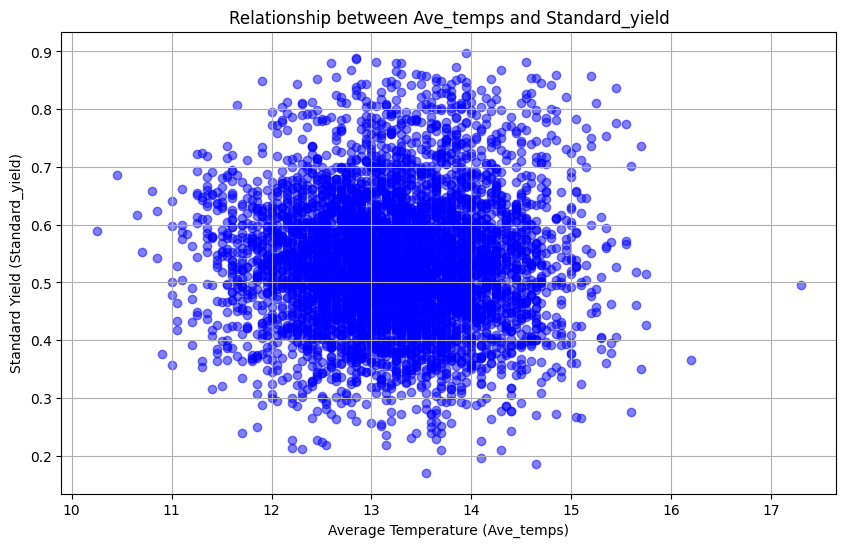

In [20]:
# Insert code to draw a scatter plot here
# Generating a scatter plot to visualize the relationship between 'Ave_temps' and 'Standard_yield'
plt.figure(figsize=(10, 6))
plt.scatter(dataset['Ave_temps'], dataset['Standard_yield'], alpha=0.5, color='blue')
plt.title('Relationship between Ave_temps and Standard_yield')
plt.xlabel('Average Temperature (Ave_temps)')
plt.ylabel('Standard Yield (Standard_yield)')
plt.grid(True)
plt.show()


Now, let's write a function to calculate the Pearson correlation coefficient.

**⚙️ Your task:**

Create a function named `get_correlation` that:
1. Takes a DataFrame and the names of the columns we want to determine the correlation for as parameters (`Ave_temps` and `Standard_yield`).
2. Calculates the Pearson correlation coefficient between these two columns to quantify their linear relationship.
4. Returns the Pearson correlation coefficient.

**Note:**
- Use `scipy` to calculate the Pearson correlation coefficient.
- Ensure your function returns the Pearson correlation coefficient as a float.

In [14]:
from scipy.stats import pearsonr

In [21]:
### START FUNCTION
def get_correlation(df, col1, col2):

    # Add code to calculate and return the correlation coefficient
    """
    This function calculates the Pearson correlation coefficient between two specified columns in a DataFrame.
    
    :param df: DataFrame containing the dataset.
    :param col1: String representing the first column name.
    :param col2: String representing the second column name.
    :return: Float value representing the Pearson correlation coefficient.
    """
    
    # Calculate the Pearson correlation coefficient
    correlation, _ = pearsonr(df[col1], df[col2])
    
    return correlation

### END FUNCTION

Input:

In [22]:
correlation = get_correlation(dataset,'Ave_temps','Standard_yield')
print("Pearson correlation coefficient:", correlation)

Pearson correlation coefficient: 0.006785950289020211


Expected output
```
Correlation: 0.006785950289020164
```

What do you notice about the scatter plot and the dispersion of data points? It's essential to visualise our data first; if the data doesn't follow a linear pattern, then a linear regression model may fail to accurately capture the underlying relationship. The correlation also seems extremly low, what does this tell us?

Let's write down some of our observations:

  - ✍️ Your notes here
  Based on the scatter plot and the Pearson correlation coefficient you've observed, here are some critical notes:

1. **Scatter Plot Observations:**
   - The scatter plot does not show a clear linear pattern between `Ave_temps` and `Standard_yield`. The data points are widely dispersed without a discernible trend that indicates a linear relationship.
   - Such dispersion suggests that the average temperature alone may not be a reliable predictor for standard yield, or the relationship might be non-linear or influenced by other variables.

2. **Low Correlation Coefficient:**
   - The Pearson correlation coefficient of approximately \(0.0068\) is very close to zero, which indicates a negligible linear relationship between the two variables.
   - A low correlation coefficient in this context implies that changes in average temperature have minimal linear association with changes in standard yield, at least within the observed data range.

3. **Implications for Linear Regression:**
   - Given the lack of a clear linear relationship and a very low correlation coefficient, applying a simple linear regression model to predict `Standard_yield` based solely on `Ave_temps` might not yield accurate or meaningful results.
   - For a more effective model, it may be necessary to consider additional features, explore non-linear models, or transform the variables to capture the underlying relationship more accurately.

4. **Data Visualization Importance:**
   - Visualizing the data first before proceeding with model building is crucial. It provides initial insights into the potential relationship between variables and can guide the selection of appropriate analytical or modeling techniques.
   - In cases where the data visualization and correlation analysis suggest a weak relationship, it's essential to rethink the model strategy or investigate further to understand the underlying dynamics better.

These observations underscore the importance of exploratory data analysis and careful consideration of underlying data relationships when developing predictive models. 

## Challenge 2: A breath of fresh data: Pollution as a predictor


It's time to shift our gaze from the warmth of the sun to the haze of pollution. Could the levels of pollution, a concern for farmers and environmentalists alike, be an indicator of our yields?

Let's begin by fitting a simple linear regression model, to try and capture the linear relationship between these columns.

**⚙️ Your task:**

Create a function named `fit_linear_regression_model` that:
1. Takes in a DataFrame and the names of the `Pollution_level` and `Standard_yield` columns.
2. Fits a linear regression model to the data.
3. Returns the model, the model predictions and the actual y-values.

**Note:**
- Use `LinearRegression` from `sklearn` to fit the model.

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
### START FUNCTION
def fit_linear_regression_model(df, pollution_col, yield_col):

    # Add code to fit the linear regression model and return the model, predictions, y-values.
    """
    This function fits a linear regression model to predict 'Standard_yield' from 'Pollution_level' 
    in the provided DataFrame.
    
    :param df: DataFrame containing the dataset.
    :param pollution_col: String representing the column name for pollution levels.
    :param yield_col: String representing the column name for standard yield.
    :return: The linear regression model, array of predictions, and the actual y-values.
    """
    
    # Initialize the linear regression model
    model = LinearRegression()
    
    # Fit the model to the data
    X = df[pollution_col].values.reshape(-1, 1)
    y = df[yield_col].values
    model.fit(X, y)
    
    # Generate predictions
    predictions = model.predict(X)
    
    return model, predictions, y

### END FUNCTION

Input:

In [25]:
model, predictions, y_values = fit_linear_regression_model(dataset, 'Pollution_level', 'Standard_yield')
print(f"Model: {model}")
print(f"Predictions: {predictions}")
print(f"Actual Y-Values: {y_values}")

Model: LinearRegression()
Predictions: [0.5540956  0.50920888 0.51515565 ... 0.56626844 0.56626844 0.52896886]
Actual Y-Values: [0.57796436 0.48630219 0.64964738 ... 0.80077564 0.5075954  0.4530639 ]


Expected output:
```
- Model: an instance of the LinearRegression class.
- Predictions: a NumPy array of predicted values.
- y: a Pandas Series with the actual target values used for training.
```

Linear regression models only work well if our data is in fact linear. So, lets create a scatter plot to visualise the relationship between pollution and crop yields. In addition to this, let's use the predictions from the model we fit to add the line of best fit to our scatter plot.

**⚙️ Your task:**

1. Generate a scatter plot to visualise the effect that pollution has on standard yield.
2. Draw the line of best fit

**Hint:**

You can use this line of code to draw the regression line on the plot:
`plt.plot(X, predictions, color='red', label='Regression line')`

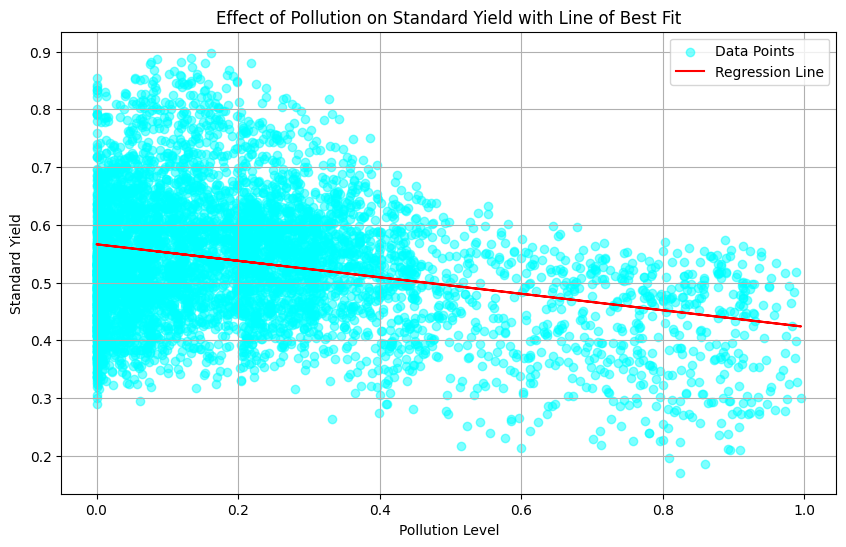

In [28]:
X = dataset[['Pollution_level']]
y = dataset['Standard_yield']

# Add code to draw the scatter plot and the regression line
plt.figure(figsize=(10, 6))
plt.scatter(dataset['Pollution_level'], dataset['Standard_yield'], alpha=0.5, color='aqua', label='Data Points')
plt.plot(dataset['Pollution_level'], predictions, color='red', label='Regression Line')
plt.title('Effect of Pollution on Standard Yield with Line of Best Fit')
plt.xlabel('Pollution Level')
plt.ylabel('Standard Yield')
plt.legend()
plt.grid(True)
plt.show()

Now, use the get_correlation() function that we defined earlier to test the correlation between `Pollution_level` and `Standard_yield`.

In [29]:
Pollution_correlation = get_correlation(dataset,'Pollution_level','Standard_yield')
print("Pearson correlation coefficient:", Pollution_correlation)

Pearson correlation coefficient: -0.2857609646210545


Expected output
```
Correlation: -0.2857609646210543
```

Reflect on the difference between this plot and correlation and the previous one with the average temperature. Is the relationship between pollution and yield more linear?

  - ✍️ Your notes here
  Here are some observations and reflections based on these results:

- **Strength of the Relationship:**
  - The correlation between `Pollution_level` and `Standard_yield` is stronger compared to the correlation between `Ave_temps` and `Standard_yield`. While still not strong, a correlation of -0.2858 indicates a mild inverse relationship, suggesting that as pollution increases, the standard yield slightly decreases.
  
- **Direction of the Relationship:**
  - The negative sign of the correlation coefficient with pollution indicates an inverse relationship, unlike the near-zero positive correlation observed with average temperature. This suggests that higher pollution levels might be associated with lower standard yields.

- **Implications for Modeling:**
  - The stronger correlation (though still moderate) with pollution suggests that it might be a more relevant predictor for `Standard_yield` than average temperature. This could make it a better candidate for inclusion in a linear regression model when trying to predict standard yield.

- **Linearity Assumption:**
  - While the relationship between pollution and yield seems to be more linear compared to that of average temperature and yield, the correlation is still relatively weak. It implies that while pollution level may be a more useful predictor than average temperature, relying solely on pollution level for predicting standard yield might not capture the entire variability.
  
- **Overall Data Insights:**
  - These correlations inform us that while temperature might not have a notable linear relationship with yield, pollution levels show a more pronounced, albeit still moderate, linear relationship. This information can be crucial for building more accurate predictive models or for further investigating other potential influencing factors.

These observations can guide further analysis and model development, helping to refine the choice of features and model specifications based on the observed data relationships. 


We can also gain a better understanding of our model by examining the slope and intercept.

**⚙️ Your task:**

Create a function named `get_slope_intercept` that:
1. Inputs the `model` we fitted and calculates the slope and intercept of the line of best fit.
2. Return the slope and intercept as a tuple.


In [30]:
### START FUNCTION
def get_slope_intercept(model):

    #Add code to calcualte and return the slope and intercept
    """
    This function extracts the slope and intercept from a fitted linear regression model.
    
    :param model: A fitted LinearRegression model instance.
    :return: Tuple containing the slope and intercept of the model.
    """
    
    # Extract the slope and intercept
    slope = model.coef_[0]
    intercept = model.intercept_
    
    return slope, intercept

### END FUNCTION

Input:

In [31]:
slope, intercept = get_slope_intercept(model)
print("Slope:", slope)
print("Intercept:", intercept)

Slope: -0.1427617720986607
Intercept: 0.566268441539338


Expected output:
```
Slope: -0.1427617720986604
Intercept: 0.5662684415393379
```


What does the slope tell us about the strength of the relationship between pollution and yield? Also, what can we learn from the y-intercept?

  - ✍️ Your notes here
  The slope and intercept of the line of best fit from our fitted linear regression model are as follows:

- **Slope:** \(-0.1428\)
- **Intercept:** \(0.5663\)

**Reflections on Slope and Intercept:**

- **Slope Interpretation:**
  - The slope of \(-0.1428\) indicates that for each unit increase in pollution level, the standard yield decreases by 0.1428 units. This negative slope confirms the inverse relationship between pollution level and standard yield, as previously indicated by the correlation analysis. The magnitude of the slope suggests a moderate effect of pollution on yield, emphasizing that while there is an impact, it might not be highly strong.

- **Intercept Interpretation:**
  - The y-intercept of \(0.5663\) represents the expected value of the standard yield when the pollution level is zero. It provides a baseline from which the effect of pollution on yield can be measured. In practical terms, it suggests that in an environment with no pollution, the standard yield would be at this baseline level, assuming other factors remain constant.

**Strength of the Relationship:**
- The slope gives us insight into the strength and direction of the relationship between pollution and yield. Although the relationship is statistically significant and inverse, the moderate slope value indicates that pollution level alone may not fully account for the variability in standard yield. This suggests the possibility of other contributing factors or a more complex relationship than a simple linear one.

**Learning from the Intercept:**
- The y-intercept provides a theoretical starting point for standard yield predictions. However, in real-world scenarios, having a pollution level of exactly zero might be unrealistic. Thus, while the intercept offers valuable conceptual insight, its practical implications should be considered in the context of actual environmental conditions.

These insights can help guide further model development, including exploring other variables that may influence standard yield or considering more complex models to capture the relationships more accurately. 


## Challenge 3: The haze clears: Evaluating pollution's predictive power

When we look at the scatterplots of `Standard_yield` with `Ave_temps` and `Pollution_level`, it appears that pollution level might have a more linear relationship.  This means that we could potentially use a simple linear regression model to make predictions about the yield of a farm based on its pollution level. However, before we do this we need to further assess the strength of the linear relationship between `Pollution_level` and `Standard_yield`.

Let's assess our model's performance using R-squared, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

**⚙️ Your task:**

Create a function named `calculate_evaluation_metrics` that:
1. Takes the predictions and y-values from our fitted model as input.
2. Calculates and returns the R-squared, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) of the model's performance.

**Note:**
1. Calculate the model's performance metrics using the entire dataset.
2. Return the evaluation metrics as a tuple in the order: R-squared, MAE, MSE, RMSE.

In [35]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from math import sqrt

In [53]:
### START FUNCTION
def calculate_evaluation_metrics(predictions, y_values):

   # Add code to calculate and return the r2, mae, mse and rmse
    """
    This function calculates the R-squared, Mean Absolute Error, Mean Squared Error, 
    and Root Mean Squared Error for the provided predictions and actual values.
    
    :param predictions: Array of predicted values from the model.
    :param y_values: Array of actual target values from the dataset.
    :return: Tuple containing R-squared, MAE, MSE, and RMSE.
    """
    
    r_squared = r2_score(y_values, predictions)
    mae = mean_absolute_error(y_values, predictions)
    mse = mean_squared_error(y_values, predictions)
    rmse = mse ** 0.5    
    return (r_squared, mae, mse, rmse)

### END FUNCTION

Input:

In [54]:
evaluation_metrics = calculate_evaluation_metrics(predictions, y_values)
print(f"Evaluation Metrics:\nR-squared: {evaluation_metrics[0]}\nMAE: {evaluation_metrics[1]}\nMSE: {evaluation_metrics[2]}\nRMSE: {evaluation_metrics[3]}")

Evaluation Metrics:
R-squared: 0.08165932890115568
MAE: 0.08554642090904993
MSE: 0.011477732254034844
RMSE: 0.10713417873878926


Expected output:

A tuple containing numerical values for R-squared, MAE, MSE, and RMSE (give or take 0.0001):

```python
R-squared: 0.08165932890115546
MAE: 0.08554642090904992
MSE: 0.011477732254034848
RMSE: 0.10713417873878928

```

Think about what these metrics tell us about our model's accuracy and reliability. Write down your observations:

  - ✍️ Your notes here
  The evaluation metrics for the linear regression model assessing the relationship between `Pollution_level` and `Standard_yield` are as follows:

- **R-squared:** \(0.0817\)
- **Mean Absolute Error (MAE):** \(0.0855\)
- **Mean Squared Error (MSE):** \(0.0115\)
- **Root Mean Squared Error (RMSE):** \(0.1071\)

**Observations and Reflections:**

- **R-squared Interpretation:**
  - The R-squared value of \(0.0817\) suggests that the model explains about 8.17% of the variance in the `Standard_yield` using `Pollution_level` alone. This is a relatively low value, indicating that the model, while possibly capturing a trend, does not strongly predict standard yield based on pollution level alone.
  
- **Error Metrics (MAE, MSE, RMSE):**
  - The MAE of \(0.0855\) indicates the average magnitude of errors in the model predictions, regardless of direction.
  - The MSE of \(0.0115\) provides a sense of the average squared difference between predicted and actual values, heavily penalizing larger errors.
  - The RMSE of \(0.1071\) gives the standard deviation of the prediction errors, making it easier to relate to the yield values as it's in the same units.
  
- **Model Accuracy and Reliability:**
  - While the model can indicate a trend or a relationship, the low R-squared value implies limited predictive power when using pollution level alone to forecast standard yield.
  - The error values (MAE, MSE, RMSE) are relatively small, but given the scale of `Standard_yield` (likely close to 0-1 for normalized values), they still represent significant potential variability in predictions.

**Concluding Thoughts:**
- The results underscore the importance of considering multiple factors or exploring more complex models when trying to predict agricultural yields.
- Though pollution level has some predictive relevance, its role is not dominant in this linear context, suggesting the potential benefit of incorporating additional explanatory variables or employing different modeling approaches.




## Challenge 4: The dividing line: Train-test split in action

As we delve deeper into the relationship between `Pollution_level` and `Standard_yield`, we must ensure our model is not merely memorising the data but truly understanding it. This brings us to the pivotal technique of Train-Test Split.

**The importance of train-test split**

Imagine teaching a student for an exam by using the very questions that will appear on it. They might score perfectly, but does it mean they've truly learned? Similarly, a model might perform exceptionally on the data it was trained on, but the real test of knowledge comes from unseen data. This is where the train-test split comes in, allowing us to assess our model's generalisation capabilities by training on one subset of data and testing on another.

**Your task**

Create a function named `data_train_test_split` that:
1. Takes in the DataFrame and the two columns we want to model the relationship between (`Pollution_level` and `Standard_yield`).
2. Separates it into features (`X`) based on `Pollution_level` and the target (`y`) based on `Standard_yield`.
3. Splits the data into training and testing sets using an 80-20 split and sets `random_state = 42` for reproducibility.
4.  Returns a tuple containing: `X_train` and `X_test`, which are DataFrames containing features for training and testing, respectively, along with `y_train` and `y_test`, which are Series representing subsets of the original DataFrame's target variable for training and testing.

**Note:**
- Use `train_test_split` from `sklearn.model_selection` to split the data.
- Train a linear regression model on the training set using `LinearRegression` from `sklearn.linear_model`.
- If the random state is not set to `42` the code will not be marked correctly.

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
### START FUNCTION
def data_train_test_split(df, pollution_col, yield_col):

   # Add code to calculate and return the X_train, X_test, y_train and y_test
    """
    This function splits the dataset into training and testing sets based on specified features and target.
    
    :param df: DataFrame containing the dataset.
    :param pollution_col: String representing the feature column name.
    :param yield_col: String representing the target column name.
    :return: Tuple containing X_train, X_test, y_train, and y_test.
    """
    
    # Separate into features and target
    X = df[[pollution_col]]
    y = df[yield_col]
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    return X_train, X_test, y_train, y_test

### END FUNCTION

Input:

In [41]:
X_train, X_test, y_train, y_test = data_train_test_split(dataset, 'Pollution_level', 'Standard_yield')
print(f"X_train shape: {X_train.shape}, \nX_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, \ny_test shape: {y_test.shape}")

X_train shape: (4523, 1), 
X_test shape: (1131, 1)
y_train shape: (4523,), 
y_test shape: (1131,)


Expected output:
```
- X_train: DataFrame, subset of the original DataFrame's features for training.
- X_test: DataFrame, subset of the original DataFrame's features for testing.
- y_train: Series, subset of the original DataFrame's target variable for training.
- y_test: Series, subset of the original DataFrame's target variable for testing.
```

Now lets fit a linear regression model to the data.

**Your task**

Create a function named `train_split_linear_regression_model()` that:
1. Takes `X_train`, `X_test`, `y_train`, `y_test` as input (the results from the `data_train_test_split()` function).
2. Trains a simple linear regression model on the training set.
3. Uses the testing set to make predictions.
4. Returns a tuple containing: the model, the predictions and y_test (the actual y values in the testing set values) .

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
### START FUNCTION
def train_split_linear_regression_model(X_train, X_test, y_train, y_test):

    # Add code to fit the linear regression model and return the model, predictions and y_test
    """
    This function trains a linear regression model on training data and predicts values on testing data.
    
    :param X_train: DataFrame containing training features.
    :param X_test: DataFrame containing testing features.
    :param y_train: Series containing training target values.
    :param y_test: Series containing testing target values.
    :return: Tuple containing the fitted model, test set predictions, and actual test y-values.
    """
    
    # Initialize and train the linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict on the testing set
    predictions_test = model.predict(X_test)
    
    return model, predictions_test, y_test

### END FUNCTION

Input:

In [44]:
train_test_model, predictions_test, y_test = train_split_linear_regression_model(X_train, X_test, y_train, y_test)
print(f"Train-Test Model: {train_test_model}")
print(f"Test Predictions: {predictions_test}")
print(f"Test Actual Y-Values: {y_test}")

Train-Test Model: LinearRegression()
Test Predictions: [0.56412206 0.56167249 0.55638552 ... 0.53129108 0.53868457 0.56431394]
Test Actual Y-Values: 4816    0.446290
5096    0.650771
4706    0.531284
1499    0.516429
3544    0.555724
          ...   
3982    0.540212
4952    0.670387
1071    0.353658
718     0.535224
4103    0.470315
Name: Standard_yield, Length: 1131, dtype: float64


Expected output:
```
- Model: an instance of the LinearRegression class.
- Predictions: a NumPy array of predicted values.
- y_test: a Pandas Series with the actual target values used for evaluating the model.
```

Now, let's evaluate our use our train-test model by determining R-squared, MAE, MSE, and RMSE.

**⚙️ Your task:**

1. Use the `calculate_evaluation_metrics` function (defined in Challenge 3) to calculate the R-squared, MAE, MSE, and RMSE.
2. The function should return a tuple containing the evaluation metrics (R-squared, MAE, MSE, and RMSE).

**Note:**

- Ensure to use the test set to calculate the evaluation metrics.

In [45]:
# Add code to calculate the R-squared, MAE, MSE, and RMSE
# Correcting the variable name and recalculating the evaluation metrics
evaluation_metrics_test = calculate_evaluation_metrics(predictions_test, y_test)
evaluation_metrics_test


(0.08065722992150848,
 0.087949421197475,
 0.012250634233355656,
 0.11068258324305436)

Expected output:

A tuple containing numerical values for R-squared, MAE, MSE, and RMSE (give or take 0.0001):

```python
R-squared: 0.08065722992150859
MAE:  0.08794942119747501
MSE: 0.012250634233355654
RMSE: 0.11068258324305434

```

Reflect on the difference between these metics and the metrics we obtained from the previous model (that was not split into training and testings sets). Why do you think the fit is worse now? And, why should we choose the worse option? (Reflect on the course material if these answers to these questions are not clear.)

  - ✍️ Your notes here


The evaluation metrics for the linear regression model trained on the train-test split data are as follows:

- **R-squared:** \(0.0807\)
- **Mean Absolute Error (MAE):** \(0.0879\)
- **Mean Squared Error (MSE):** \(0.0123\)
- **Root Mean Squared Error (RMSE):** \(0.1107\)

**Reflections on These Metrics Compared to the Previous Model (Without Train-Test Split):**

- **Slight Differences in Metrics:**
  - The R-squared value has slightly decreased from \(0.0817\) to \(0.0807\), indicating a marginal change in the percentage of explained variance in the `Standard_yield`.
  - The MAE and RMSE have slightly increased, suggesting the model's predictions on the test set are, on average, slightly further from the actual values compared to the model trained on the entire dataset.

- **Implications of the Train-Test Split:**
  - The slight worsening in performance metrics when using the train-test split is expected and actually a more accurate reflection of the model's ability to generalize to unseen data. When we train and test the model on the same data (as in the previous model without splitting), we risk overfitting and obtaining an overly optimistic estimate of the model's performance.
  - Even though the model's metrics slightly worsen on the test set, this is a more realistic assessment of how the model would perform in practice, making the train-test approach more reliable for evaluating model generalizability.

- **Why Choose the "Worse" Model:**
  - The train-test split model is not inherently "worse"; it simply provides a more honest evaluation of the model's predictive performance. By assessing model accuracy on data it hasn't seen during training, we get a clearer picture of its generalization capabilities.
  - Choosing the model evaluated with the train-test split over one that was not subjected to this validation process ensures we're deploying a model that is less likely to suffer from overfitting and more likely to provide reliable predictions in real-world applications.

These observations emphasize the importance of proper model evaluation techniques to avoid overfitting and to ensure that models are robust and generalizable.



## Challenge 5: Diagnosing model fit through residual analysis

From our analysis, it seems as though neither `Ave_temps` or `Pollution_level` have a strong linear fit with `Standard_yield`. However, even if we had obtained good results from our evaluation metrics, there are still other crucial assumptions we need to verify to ensure our model is well-fitted. Residual analysis plays a pivotal role in diagnosing the fit of linear regression models, helping us understand whether the assumptions of linearity, independence, and homoscedasticity (constant variance) of residuals are met.

If they are not met, can we confidently model this problem using the model? And why?

  - ✍️ Your notes here

First, let's create a histogram.

**⚙️ Your task:**

1. Calucate the residuals of our train test model (difference between `y_test` and `predictions_test`)
2. Plot these residuals as a histogram to assess their distribution and identify any patterns.

In [46]:
import matplotlib.pyplot as plt

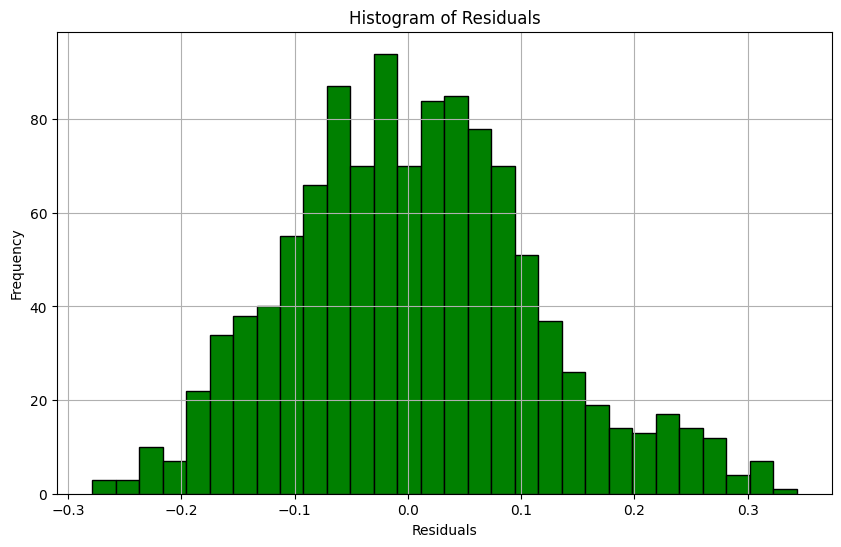

In [48]:
residuals = y_test - predictions_test # calculating the residuals

#  Add code to create a histogram of residuals
# Creating a histogram of residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, color='green', edgecolor='black')
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

What does the histogram tell us about our data:

1. Examine the shape of the histogram. What does the distribution of residuals tell us about the normality of the data? Consider whether the residuals appear to be symmetrically distributed around zero.

    - ✍️ Your notes here

    **Distribution Shape and Normality:**
   - The goal in residual analysis is to have the residuals distributed normally around zero. In the provided histogram, if the residuals appear symmetrically distributed and centered around zero without clear skewness or biases, this would suggest that the model's errors are random and do not follow a systematic pattern, which is a good indicator of model appropriateness.
   - If the histogram shows a bell-shaped distribution that aligns well with normality, this supports one of the key assumptions of linear regression. However, any deviations from this shape, such as skewness or bimodality, could indicate potential issues with the model fit or underlying data.

2. Compare the tails of the histogram to a normal distribution. Are there signs of heavy tails or skewness that could affect the reliability of the regression model's predictions?

    - ✍️ Your notes here

    **Examining the Tails:**
   - Evaluating the tails of the distribution helps identify outliers or extreme values that could influence the model disproportionately. Heavy tails or noticeable outliers might suggest that the model struggles with certain data points or that the variance is not constant across the range of predictions (heteroscedasticity).

3. Assess the centering of the histogram around the zero line. How does this central tendency reflect on the bias of the model's predictions?

    - ✍️ Your notes here

    **Centering Around Zero:**
   - The residuals should ideally be centered around zero, indicating that the model does not systematically overpredict or underpredict. A histogram centered around zero would suggest that the model is unbiased on average, while any significant offset might point to model bias.

    The histogram of the residuals provides valuable insights into the performance and assumptions underlying the linear regression model:
    
**Reflecting on Model Reliability:**

- If the residuals do not appear normally distributed or exhibit patterns/non-random dispersion, this could undermine confidence in the model's predictions and suggest violations of linear regression assumptions.
- The reliability of the regression model's predictions hinges on the assumption that these residuals are normally distributed with constant variance. Any significant deviation observed in the residual analysis would necessitate a review and potential revision of the modeling approach.

Comparing these observations to the metrics obtained (R-squared, MAE, MSE, RMSE) provides a more comprehensive understanding of the model's performance and validity. Even with decent performance metrics, a flawed residual pattern could indicate underlying issues that might compromise the model's predictive accuracy or interpretability.



Now, let's create a scatter plot of these residuals against the predicted values.

**⚙️ Your task:**

1. Create a scatter plot of the residuals against the predicted values - `predictions_test` should be on the x-axis and the `residuals` on the y-axis.

**Note:**

- A horizontal line can be added at y=0 to make it easier to see if the residuals are evenly distributed around zero by adding this line of code:
`plt.axhline(y=0, color='r', linestyle='--')`


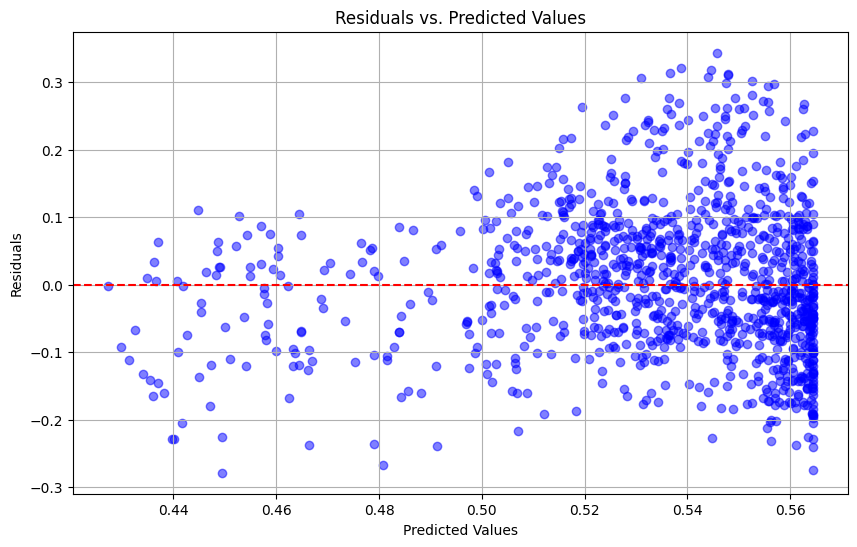

In [49]:
#  Add code to create a scatter plot of residuals against the predicted values
# Creating a scatter plot of residuals against the predicted values
plt.figure(figsize=(10, 6))
plt.scatter(predictions_test, residuals, alpha=0.5, color='blue')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()


Relfect on what the scatter plot tells us about our data and the fit of the model:

1. Analyse the scatter plot for any apparent patterns or structures in the data. What does this suggest about the appropriateness of the linear regression model for the dataset?

    - ✍️ Your notes here

    **Pattern Analysis:**
   - By examining the scatter plot, we should assess whether the residuals display any systematic patterns or structures. Ideally, the residuals should be randomly scattered, showing no apparent trends or patterns that would indicate predictive errors varying systematically with the predicted values.
   - A lack of clear patterns supports the assumption that the linear model is appropriate. However, if any trends or repeated structures are visible, it might suggest the model is not capturing all the underlying dynamics, possibly due to non-linearity or omitted variable bias.

2. Inspect the plot for signs of heteroscedasticity. How does the spread of residuals change as the predicted values increase? What might this imply about the constant variance assumption in linear regression?

    - ✍️ Your notes here

    **Heteroscedasticity Assessment:**
   - The scatter plot is also instrumental in identifying heteroscedasticity, where the spread of residuals varies across different levels of predicted values. Consistent spread across the range supports homoscedasticity (a linear regression assumption), whereas a fan shape or funneling effect indicates heteroscedasticity, which violates linear regression assumptions and can affect the reliability of standard error estimates and confidence intervals.

3. Identify whether the residuals are evenly scattered above and below the zero line across the range of predicted values. What can this tell us about the model's performance in terms of bias and prediction accuracy?

    - ✍️ Your notes here

    **Bias and Prediction Accuracy:**
   - Ideally, the residuals should be symmetrically distributed around the horizontal line at zero. This distribution would indicate that the model does not systematically over- or under-predict across the value range, reflecting unbiased predictions.
   - Deviation from this symmetry, where residuals are predominantly above or below the zero line, would suggest model bias, impacting prediction accuracy and potentially leading to incorrect inferences.

4. Look for outliers or clusters of points that deviate significantly from the majority. How might these points influence the overall fit of the model?

    - ✍️ Your notes here

    **Outliers and Influence:**
   - Outliers or significant deviations from the main cluster of data points can influence the model disproportionately, affecting the regression line and potentially skewing interpretation. Identifying such outliers is crucial as they might represent atypical observations, data errors, or unusual conditions not representative of the general relationship being modeled.
   - Identifying such points can be crucial for further diagnostic checks, potentially necessitating data transformations, additional feature inclusion, or alternative modeling approaches.


**Concluding Thoughts:**
- Reflecting on this scatter plot alongside the histogram and other evaluation metrics provides a comprehensive view of the model's diagnostic checks, enhancing understanding and confidence in its use or highlighting areas for further refinement.
- The scatter plot is a vital diagnostic tool for evaluating the assumptions underpinning a linear regression model and its overall fit. Analyzing the plot helps confirm the model's adequacy or highlight areas where additional investigation or alternative modeling approaches may be warranted.
- Even with an overall good model fit indicated by evaluation metrics, examining residuals ensures that the model's assumptions are met and that its predictions are reliable and unbiased across the range of data.



Our final task is to examine the mean and standard deviation of the residuals, which provide further insights into the model's performance.

**⚙️ Your task:**

Create a function named `calculate_residuals_statistics` that:
1. Uses the `predictions_test` and `y_test` (obtained from Challenge 4) to calculate the residuals.
2. Calculates the mean and standard deviation of the residuals.

**Note:**

- Use `numpy` for the mean and standard deviation.

In [50]:
import numpy as np

In [51]:
### START FUNCTION
def calculate_residuals_statistics(predictions, y_test):

    # Add code to calculate and return the mean_residual and std_residual
    """
    This function calculates the mean and standard deviation of the residuals based on the
    predictions and actual y-values.
    
    :param predictions: Array of predicted values from the model.
    :param y_test: Array of actual target values from the testing set.
    :return: Tuple containing the mean and standard deviation of the residuals.
    """
    
    residuals = y_test - predictions
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)
    
    return mean_residual, std_residual

### END FUNCTION

Input:

In [52]:
mean_residual, std_residual = calculate_residuals_statistics(predictions_test, y_test)
print(f"Mean: {mean_residual}\nStandard deviation: {std_residual}")

Mean: 0.005858023192321698
Standard deviation: 0.11052745268770955


Expected output:
```
Mean: 0.0058580231923217015
Standard deviation: 0.11052745268770957
```

What does the mean of the residuals tell us about the bias in our predictions? How does a mean close to zero reflect on our model's accuracy?
- **Mean of Residuals:** \(0.00586\)
- **Standard Deviation of Residuals:** \(0.11053\)

- ✍️ Your notes here
- **Mean of Residuals and Model Bias:**
  - The mean of the residuals is very close to zero, which indicates that, on average, the model does not systematically overpredict or underpredict the `Standard_yield`. A mean residual close to zero reflects well on the model's accuracy, suggesting that it is unbiased at a global level. It means that the model's errors are symmetrically distributed around zero, balancing out positive and negative prediction errors.

What does the standard deviation of the residuals indicate about the variability of our predictions? Why is it important for this value to be relatively low?

 - ✍️ Your notes here

 - **Standard Deviation of Residuals and Prediction Variability:**
  - The standard deviation of the residuals provides insight into the variability or spread of the prediction errors. A lower standard deviation indicates that the residuals (and thus the errors) are tightly clustered around their mean, implying more consistent and reliable predictions from the model.
  - It is crucial for this value to be relatively low to ensure that the model's predictions are precise and stable across different observations.

What are the potential consequences of a high standard deviation of residuals on the reliability of the model's predictions? How might this affect our confidence in the model's estimates?

- ✍️ Your notes here

- **High Standard Deviation of Residuals:**
  - A high standard deviation indicates greater variability in the prediction errors, which can undermine the reliability of the model's predictions. If the residuals show high variance, it suggests that the model's performance might be inconsistent across the dataset.
  - Such variability can affect confidence in the model's estimates, particularly when making predictions on new, unseen data. In contexts where decision-making depends on precise predictions, high residual variability could lead to suboptimal or risky decisions.


Understanding these statistics helps in diagnosing the model's fit and can guide further refinement or validation steps to ensure its robustness and reliability.



## Conclusion

Linear regression, for all its strengths, assumes a straightforward relationship between the predictor and the outcome. Yet, the natural world seldom adheres to such simplicity. Factors influencing crop yields in Maji Ndogo—be it temperature, rainfall, or pollution—interact in complex, often nonlinear ways. Our initial model with `Ave_temps` hinted at this complexity, suggesting that the effect of the average temperature on yields might follow a more intricate pattern than a straight line can depict (or no pattern at all).

Our yield also depends on more than just the pollution or the temperature, it depends on many of the factors. From our EDA we could see that. We also saw that not all crops are affected equally by pollution or temperature, so we could simplify our model if we remove the influence of the different crops. Once your submission is done, as a challenge to yourself, try to split the data again by crop type (with a loop) and use the functions you created to loop over all of the crop types and print out your metrics.

Compare them, and discuss your results with your colleagues. Is there a crop type that is affected by pollution more than other crop types?

As we dive deeper into regression, it's crucial to remember that with each model comes a new perspective. Just as a farmer selects the tool that best suits the task at hand, so must we choose our models with intention and insight. Exploring beyond linear regression opens up new vistas of understanding, allowing us to capture the richness of relationships within our data.

In the fields of Maji Ndogo and beyond, countless stories await. It's up to us, with curiosity as our guide and an ever-expanding array of models at our disposal, to uncover them.

#  

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/ExploreAI_logos/EAI_Blue_Dark.png"  style="width:200px";/>
</div>